# Версия Python: 3.7
# Версии библиотек:
-i https://pypi.org/simple
brotli==1.0.9
click==8.0.3; python_version >= '3.6'
colorama==0.4.4; platform_system == 'Windows'
dash==2.1.0
dash-bootstrap-components==1.0.3
dash-core-components==2.0.0
dash-html-components==2.0.0
dash-table==5.0.0
flask==2.0.3; python_version >= '3.6'
flask-compress==1.10.1
gunicorn==20.1.0
importlib-metadata==4.11.1; python_version < '3.8'
itsdangerous==2.0.1; python_version >= '3.6'
jinja2==3.0.3; python_version >= '3.6'
markupsafe==2.0.1; python_version >= '3.6'
numpy==1.21.5; python_version < '3.10' and platform_machine != 'aarch64' and platform_machine != 'arm64'
packaging==21.3; python_version >= '3.6'
pandas==1.3.5
patsy==0.5.2
plotly==5.6.0; python_version >= '3.6'
pyparsing==3.0.7; python_version >= '3.6'
python-dateutil==2.8.2; python_version >= '2.7' and python_version not in '3.0, 3.1, 3.2, 3.3'
pytz==2021.3
scipy==1.7.3; python_version < '3.11' and python_version >= '3.7'
setuptools==60.9.3; python_version >= '3.7'
six==1.16.0; python_version >= '2.7' and python_version not in '3.0, 3.1, 3.2, 3.3'
statsmodels==0.13.2
tenacity==8.0.1; python_version >= '3.6'
typing-extensions==4.1.1; python_version < '3.8'
werkzeug==2.0.3; python_version >= '3.6'
zipp==3.7.0; python_version >= '3.7'

# Команда запуска:

In [ ]:
!python run.py

Traceback (most recent call last):
  File "../run.py", line 8, in <module>
    from pages import index, predictions
  File "/home/kirill/lab_3_ai/lab_1/Fish-Dimensions-Regression-Analysis/pages/index.py", line 24, in <module>
    df = pd.read_csv('./assets/data/Fish.csv')
  File "/home/kirill/lab_3_ai/lab_1/Fish-Dimensions-Regression-Analysis/env/lib/python3.7/site-packages/pandas/util/_decorators.py", line 311, in wrapper
    return func(*args, **kwargs)
  File "/home/kirill/lab_3_ai/lab_1/Fish-Dimensions-Regression-Analysis/env/lib/python3.7/site-packages/pandas/io/parsers/readers.py", line 586, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/home/kirill/lab_3_ai/lab_1/Fish-Dimensions-Regression-Analysis/env/lib/python3.7/site-packages/pandas/io/parsers/readers.py", line 482, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/home/kirill/lab_3_ai/lab_1/Fish-Dimensions-Regression-Analysis/env/lib/python3.7/site-packages/pandas/io/parsers/readers.

Ошибки при первой попытке установить зависимости:

In [ ]:
!pipenv install --deploy --ignore-pipfile

# Вывод:
Warning: Python 3.7 was not found on your system...
Neither 'pyenv' nor 'asdf' could be found to install Python.
You can specify specific versions of Python with:
$ pipenv --python path/to/python

Требуется Python 3.7
Устанавливаем нужную версию python 3.7.

In [ ]:
!pyenv install 3.7.17

Вторая попытка установить зависимости:

In [ ]:
!pipenv install --deploy --ignore-pipfile

# Вывод:
This version of pip does not support python 3.7 (requires >=3.10).
ERROR: Couldn't install package(s): brotli==1.0.9

Python 3.7 не работает с новой версией pip. Поэтому удаляем созданное с помощью pipenv окружение, устанавливаем поддерживаемую версию pip(до 24.1) и создаем виртуальное окружение вручную с помощью стандартных инструментов python. После чего устанавливаем зависимости.

In [ ]:
!pipenv --rm
!pipenv requirements > requirements.txt
~/.pyenv/versions/3.7.17/bin/python3.7 -m venv env
source .venv/bin/activate
!python -m pip install --upgrade "pip<24.1"
!pip install -r requirements.txt

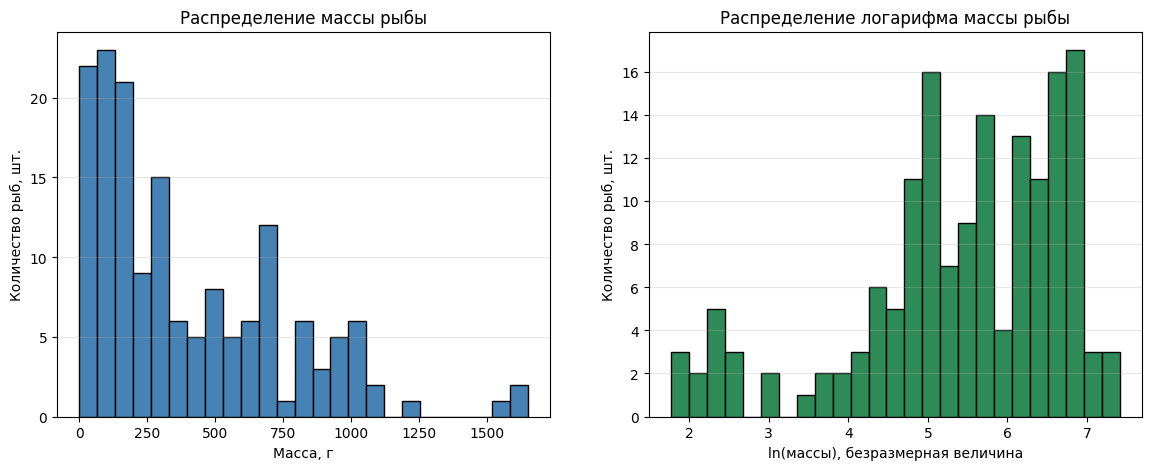

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../assets/data/Fish.csv")
df = pd.read_csv(DATA_PATH)

target = df["Weight"]
log_weight = np.log(target[target > 0])  # исключаем нулевую массу

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target, bins=25, color="steelblue", edgecolor="black")
axes[0].set_title("Распределение массы рыбы")
axes[0].set_xlabel("Масса, г")
axes[0].set_ylabel("Количество рыб, шт.")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(log_weight, bins=25, color="seagreen", edgecolor="black")
axes[1].set_title("Распределение логарифма массы рыбы")
axes[1].set_xlabel("ln(массы), безразмерная величина")
axes[1].set_ylabel("Количество рыб, шт.")
axes[1].grid(axis="y", alpha=0.3)

plt.show()



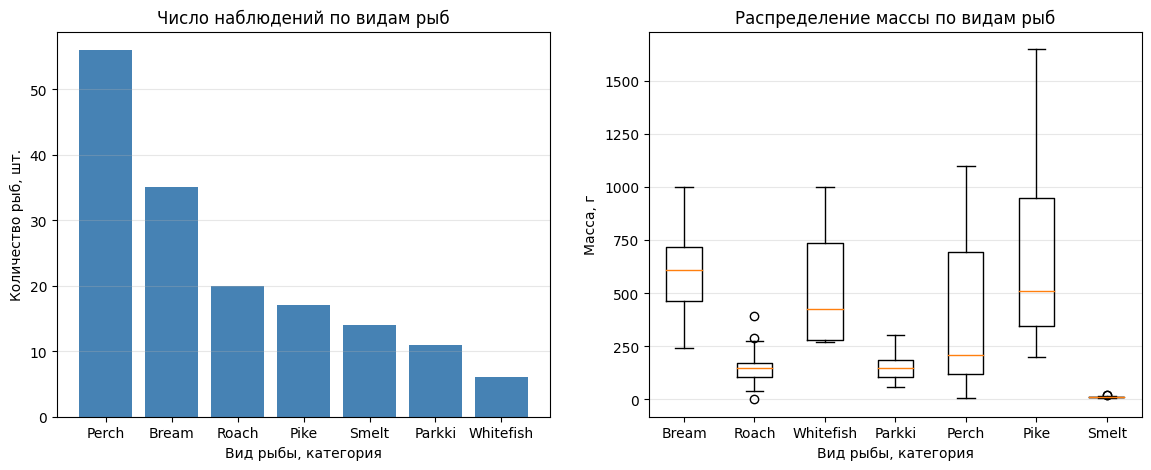

In [22]:
species = df["Species"].unique()
weights_by_species = [df.loc[df["Species"] == sp, "Weight"] for sp in species]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df["Species"].value_counts().index, df["Species"].value_counts().values, color="steelblue")
axes[0].set_title("Число наблюдений по видам рыб")
axes[0].set_xlabel("Вид рыбы, категория")
axes[0].set_ylabel("Количество рыб, шт.")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(weights_by_species, labels=species)
axes[1].set_title("Распределение массы по видам рыб")
axes[1].set_xlabel("Вид рыбы, категория")
axes[1].set_ylabel("Масса, г")
axes[1].grid(axis="y", alpha=0.3)
plt.show()

**Вывод.** Выборка по видам несбалансирована: Perch представлен 56 наблюдениями, Whitefish — 6. Масса также заметно отличается между видами, поэтому вид следует учитывать при анализе и моделировании.

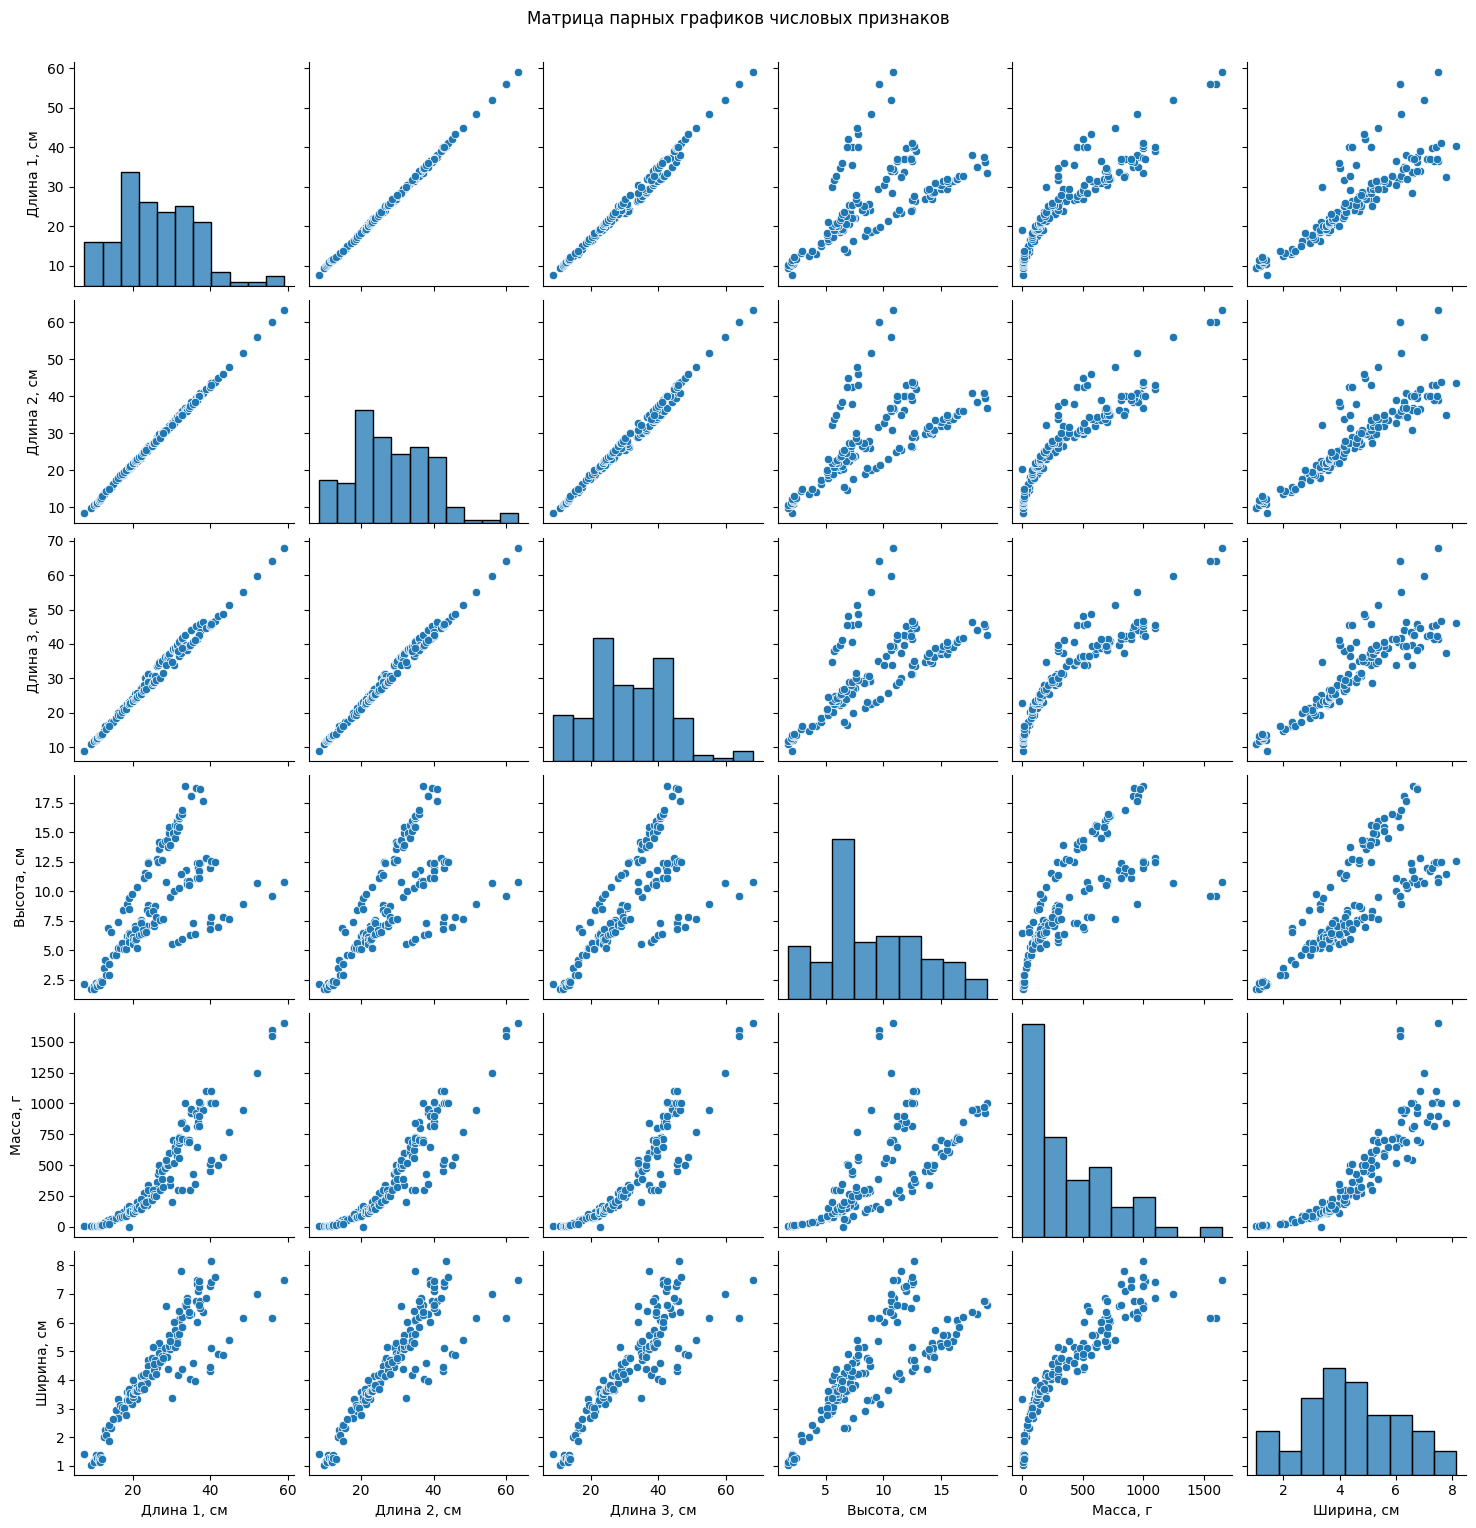

In [5]:
import seaborn as sns

selected_features = ["Length1", "Length2", "Length3", "Height", "Weight", "Width"]
axis_names = {"Length1": "Длина 1, см", "Length2": "Длина 2, см", "Length3": "Длина 3, см", "Height": "Высота, см", "Weight": "Масса, г", "Width": "Ширина, см"}
g = sns.pairplot(df[selected_features], diag_kind="hist")
for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax is not None:
            ax.set_xlabel(axis_names[g.x_vars[j]])
            ax.set_ylabel(axis_names[g.y_vars[i]])
g.fig.suptitle("Матрица парных графиков числовых признаков", y=1.02)
plt.show()

**Вывод.** Масса растёт вместе с размерами рыбы; особенно заметна связь с Length3. Показатели Length1, Length2 и Length3 почти линейно связаны друг с другом, поэтому в регрессионной модели возможна мультиколлинеарность.

In [7]:
correlation_matrix = df.corr()
print(correlation_matrix)


           Weight   Length1   Length2   Length3    Height     Width
Weight   1.000000  0.915712  0.918618  0.923044  0.724345  0.886507
Length1  0.915712  1.000000  0.999517  0.992031  0.625378  0.867050
Length2  0.918618  0.999517  1.000000  0.994103  0.640441  0.873547
Length3  0.923044  0.992031  0.994103  1.000000  0.703409  0.878520
Height   0.724345  0.625378  0.640441  0.703409  1.000000  0.792881
Width    0.886507  0.867050  0.873547  0.878520  0.792881  1.000000


**Вывод.** Коэффициенты Пирсона подтверждают сильную положительную линейную связь массы с длинами, но не доказывают отсутствие нелинейных связей: корреляция измеряет только линейную зависимость и чувствительна к выбросам.

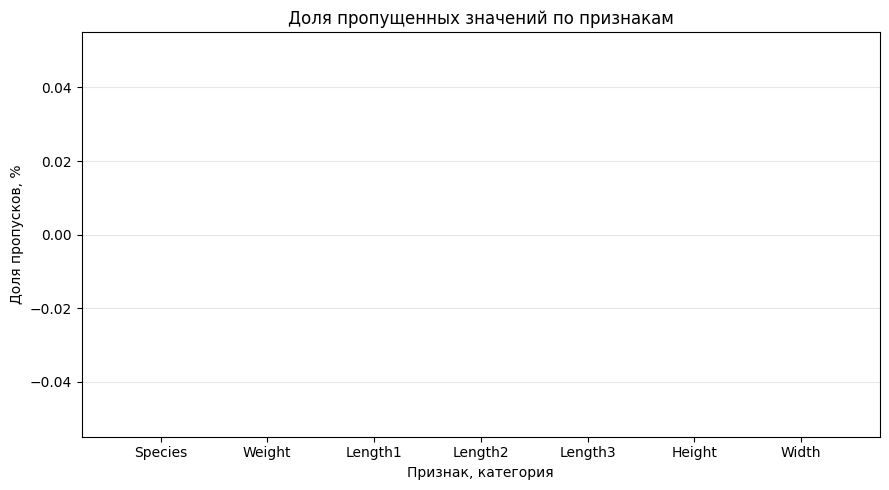

In [7]:
missing_share = df.isna().sum()
plt.figure(figsize=(9, 5))
plt.bar(missing_share.index, missing_share.values, color="slateblue")
plt.title("Доля пропущенных значений по признакам")
plt.xlabel("Признак, категория")
plt.ylabel("Доля пропусков, %")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод.** В наборе данных нет пропущенных значений: доля пропусков для каждого признака равна 0 %. Это устраняет необходимость в заполнении пропусков, но не отменяет проверку нулевых и аномальных значений.

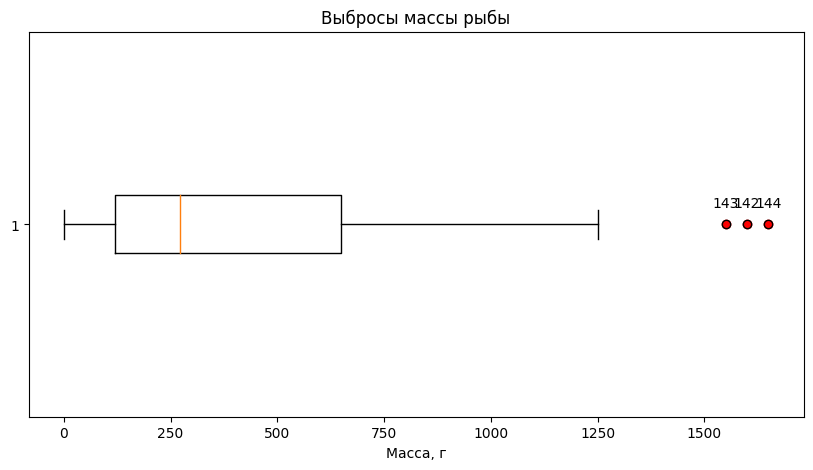

    Species  Weight  Length1  Length2  Length3  Height  Width
142    Pike  1600.0     56.0     60.0     64.0   9.600  6.144
143    Pike  1550.0     56.0     60.0     64.0   9.600  6.144
144    Pike  1650.0     59.0     63.4     68.0  10.812  7.480


In [16]:
q1 = df["Weight"].quantile(0.25)
q3 = df["Weight"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
outliers = df[df["Weight"] > upper_bound]

plt.figure(figsize=(10, 5))
plt.boxplot(df["Weight"], vert=False)

for index, value in outliers["Weight"].items():
    plt.scatter(value, 1, color="red")
    plt.annotate(
        f"{index}",
        (value, 1),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center"
    )

plt.title("Выбросы массы рыбы")
plt.xlabel("Масса, г")
plt.show()
print(outliers)


**Вывод.** По правилу 1,5 IQR выбросами массы являются строки 142, 143 и 144 (нумерация DataFrame начинается с нуля). Их не следует автоматически удалять: это могут быть корректные наблюдения очень крупных рыб.

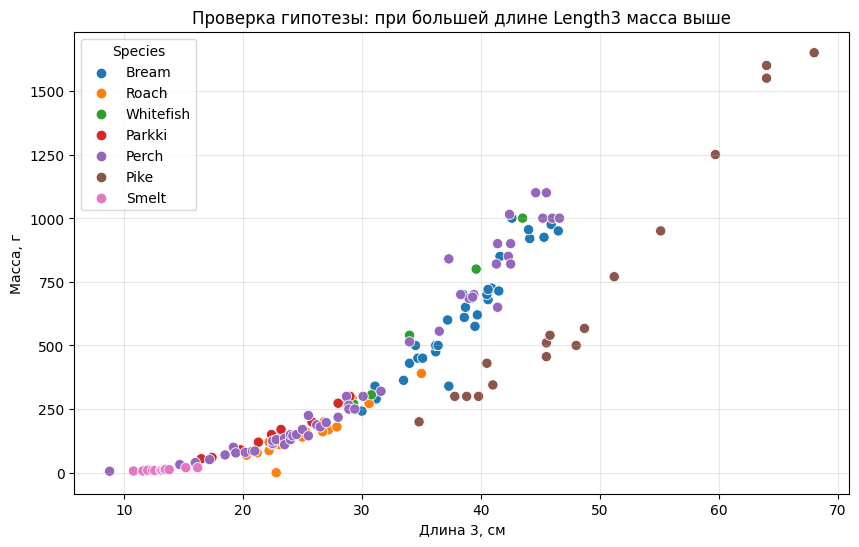

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Length3", y="Weight", hue="Species", s=55)
plt.title("Проверка гипотезы: при большей длине Length3 масса выше")
plt.xlabel("Длина 3, см")
plt.ylabel("Масса, г")
plt.grid(alpha=0.3)
plt.show()

**Вывод.** Гипотеза подтверждается: у рыб большей длины Length3 обычно больше масса. Одновременно облака точек разных видов расположены по-разному, поэтому для прогноза одной длины недостаточно — в модель стоит включить вид рыбы.

**IQR для Weight.** 

In [11]:
feature = "Weight"
x = df[feature]

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

median = x.median()
mad = (x - median).abs().median()
robust_z = 0.6745 * (x - median) / mad

iqr_rows = df.index[(x < lower_bound) | (x > upper_bound)]
mad_rows = df.index[robust_z.abs() > 3.5]

print("Границы IQR:", lower_bound, upper_bound)
print("Подозрительные строки по IQR:", iqr_rows.tolist())
print("Подозрительные строки по MAD:", mad_rows.tolist())


Границы IQR: -675.0 1445.0
Подозрительные строки по IQR: [142, 143, 144]
Подозрительные строки по MAD: [142, 143, 144]


**Вывод.** Методами IQR и MAD выявлены строки 142, 143 и 144 как выбросы по
признаку Weight. Во всех трёх строках указан вид Pike (большие
значения массы (1550–1650 г) согласованы с увеличенными длинами рыб).
Поэтому значения не выглядят ошибками ввода и не удаляются. Для
контроля влияния крупных рыб на модель добавлен бинарный признак
weight_outlier, равный 1 для подозрительных строк. При построении
модели можно дополнительно сравнить метрики на полной выборке и на
выборке без этих строк.

In [12]:
df["Weight_outlier"] = (df.index.isin(iqr_rows) | df.index.isin(mad_rows))


## Гипотезы
**1. Физическая гипотеза:**
   Масса рыбы растет с ее приближенным объемом.
   V = Length3 * Height * Width

**2. Гипотиза:**
   Связь длины Length3 и массы различаются между видами.

## Проверка гипотиз:

<Figure size 1000x600 with 0 Axes>

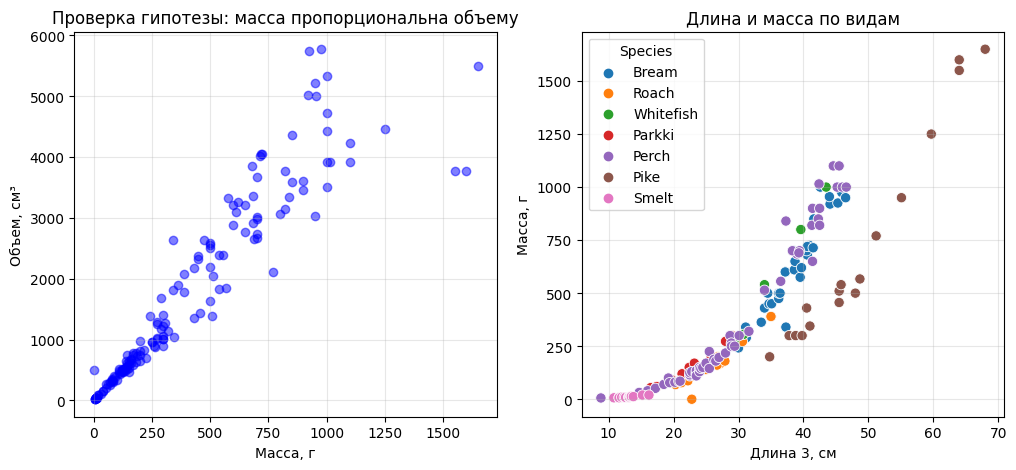

In [25]:
plt.figure(figsize=(10, 6))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df["Weight"], df["Length3"]*df["Width"]*df["Height"], c="blue", alpha=0.5)
axes[0].set_title("Проверка гипотезы: масса пропорциональна объему")
axes[0].set_xlabel("Масса, г")
axes[0].set_ylabel("Объем, см³")
axes[0].grid(alpha=0.3)

sns.scatterplot(
      data=df,
      x="Length3",
      y="Weight",
      hue="Species",
      s=55,
      ax=axes[1]
  )
axes[1].set_title("Длина и масса по видам")
axes[1].set_xlabel("Длина 3, см")
axes[1].set_ylabel("Масса, г")
axes[1].grid(alpha=0.3)

plt.show()

**Вывод.** На первом графике видно, что с увеличением приближённого объёма рыбы её масса в целом растёт. Это подтверждает физически обоснованную гипотезу: более крупная рыба обычно тяжелее.

На втором графике точки разных видов образуют отдельные группы. При одинаковой длине `Length3` масса рыб может различаться в зависимости от вида. Следовательно, для прогнозирования массы недостаточно использовать только длину (категориальный признак `Species` также следует включить в модель).

Признак `Species` является категориальным, поэтому для него используется One-Hot
Encoding: для каждого вида создаётся отдельный бинарный столбец. При появлении
нового вида применяется handle_unknown="ignore": ошибка не возникает,
неизвестная категория кодируется нулевыми значениями. В этом случае прогноз
cтроится преимущественно по числовым признакам, поэтому новый вид следует
зафиксировать и добавить в обучающую выборку при следующем переобучении модели.

Признаки `Length1`, `Length2` и `Length3` имеют очень высокую взаимную корреляцию,
близкую к 1. Это означает мультиколлинеарность (линейная модель может давать
нестабильные коэффициенты для отдельных длин, хотя общий прогноз останется
хорошим). Автоматически удалять признаки только по порогу корреляции не следует,
так как каждый показатель длины может иметь отдельный физический смысл.

Для борьбы с мультиколлинеарностью можно  оставить
один осмысленно выбранный признак длины (`Length3`)или
использовать приближённый объём вместо набора отдельных размеров. Окончательный
вариант выбирается по качеству на тестовой выборке.
